# Analiticos para analizar los sentimientos de las notas

En jupyter notebook se hara un analisis de las notas creadas en el pagina de David, como parte del coding challenge de pey

In [ ]:
#Poner las variables para obtener los datos
GRAPHQL_ENDPOINT = ""
API_KEY = ""

In [15]:
import requests

HEADERS = {
    "Content-Type": "application/json",
    "x-api-key": API_KEY,
}

QUERY = """
query GetNotes($sentiment: Sentiment, $limit: Int, $nextToken: String) {
  getNotes(sentiment: $sentiment, limit: $limit, nextToken: $nextToken) {
    items {
      id
      text
      sentiment
      dateCreated
    }
    nextToken
    scannedCount
  }
}
"""

variables = {
    "sentiment": None,
    "nextToken": None
}


def fetch_all_notes(sentiment=None, limit=10):
    all_notes = []
    next_token = None
    page = 1

    while True:
        variables = {
            "sentiment": sentiment,
            "limit": limit,
            "nextToken": next_token
        }
        payload = {"query": QUERY, "variables": variables}

        response = requests.post(GRAPHQL_ENDPOINT, headers=HEADERS, json=payload, timeout=30)
        data = response.json()

        if "errors" in data:
            print("Error:", data["errors"])
            break

        result = data["data"]["getNotes"]
        items = result["items"]
        all_notes.extend(items)

        print(f"Página {page}: {len(items)} notas | total acumulado: {len(all_notes)}")

        next_token = result.get("nextToken")
        page += 1

        if not next_token:
            print("Ya no hay más páginas.")
            break

    return all_notes


notes = fetch_all_notes()

Página 1: 10 notas | total acumulado: 10
Página 2: 2 notas | total acumulado: 12
Ya no hay más páginas.


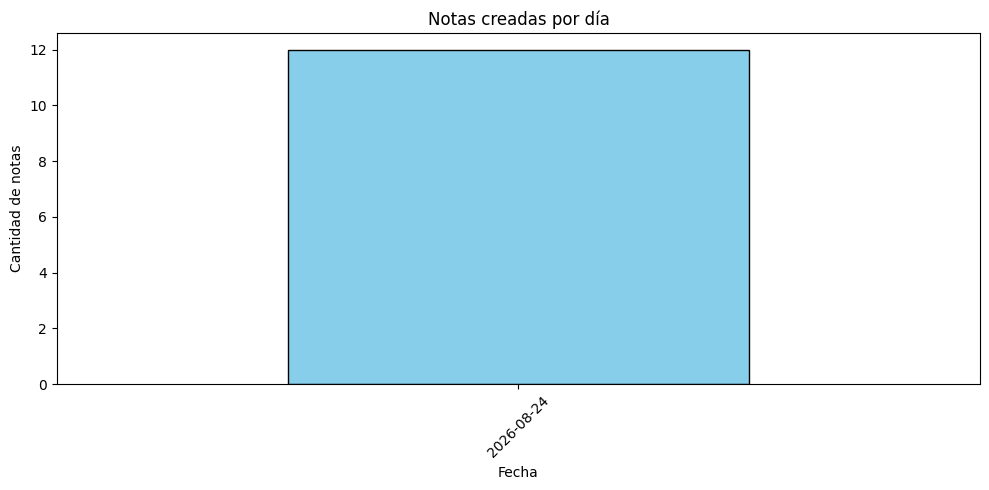

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Convertir a DataFrame
df = pd.DataFrame(notes)

# Convertir dateCreated a datetime y extraer solo la fecha (sin hora)
df['fecha'] = pd.to_datetime(df['dateCreated']).dt.date

# Contar notas por día
conteo_por_dia = df['fecha'].value_counts().sort_index()

# Graficar
plt.figure(figsize=(10, 5))
conteo_por_dia.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de notas')
plt.title('Notas creadas por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

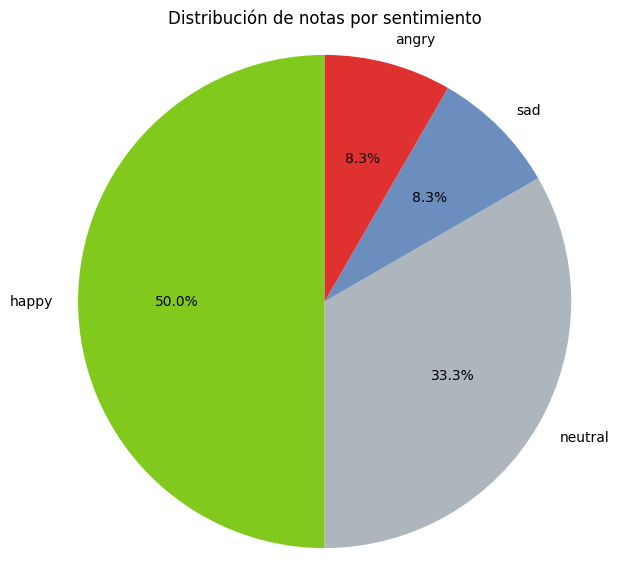

In [ ]:
# Contar cuántas notas hay por sentimiento
conteo_sentimientos = df['sentiment'].value_counts()

colores_sentimiento = {
    'sad': '#6c8ebf',
    'happy': '#82c91e',
    'angry': '#e03131',
    'neutral': '#adb5bd'
}

colores = [colores_sentimiento.get(s, '#cccccc') for s in conteo_sentimientos.index]

plt.figure(figsize=(7, 7))
plt.pie(conteo_sentimientos, labels=conteo_sentimientos.index, autopct='%1.1f%%',
        colors=colores, startangle=90)
plt.title('Distribución de notas por sentimiento')
plt.axis('equal')
plt.show()